# XLPSR — SOTA Pipeline Comparison

**Goal.** Beat the previous demo (which scored **−72/564 = −12.8%** on the dev set, **0/39** exact matches).

**Why we lost so badly last time.** The XLPSR scoring rewards correct chars (+2), penalises wrong chars (−1), and gives 0 for omissions. The previous Swin2SR + PaddleOCR pipeline hallucinated dictionary-like words ("NOSE", "JNAY", "I0TAL"), so almost every guess subtracted points. The fix is *fewer wrong characters*, not necessarily more correct ones.

**What this notebook does.**
1. Loads the 39 dev sequences (10 LR frames + bbox each, French plates).
2. Picks sharp frames with **Laplacian variance**.
3. Runs a *zoo* of super-resolution models — **Bicubic, Swin2SR, SwinIR, Real-ESRGAN, HAT, Stable-Diffusion x4 Upscaler**.
4. Runs a *zoo* of OCR engines — **PaddleOCR, EasyOCR, TrOCR (Microsoft), Florence-2 (VLM)**.
5. Fuses multi-frame predictions with **MVCP** (majority vote per character position) + confidence-weighted voting.
6. Enforces **French plate format** (SIV `AA-123-AA` and old `123-AAA-12`/`1234-AA-12`) and applies confidence-thresholded omission to dodge the −1 penalty.
7. Runs a **grid evaluation** (SR × OCR × K-frames) so we can see exactly where each combination wins or loses.
8. Generates a `predictions.csv` for the best config and lists concrete fine-tuning next steps.

> **Hardware note.** Built to run on a CPU-only laptop. Heavy models (HAT, SD x4, Florence-2-large) are gated behind feature flags in the config cell — leave them off for a fast first pass and switch them on when you have time/GPU.


In [1]:
# ============================================================
# (Optional) Install missing dependencies. Restart kernel after.
# ============================================================
# !pip install -q transformers timm accelerate einops huggingface_hub
# !pip install -q paddleocr==2.9.1 paddlepaddle==2.6.2 easyocr
# !pip install -q opencv-python-headless Pillow scikit-image
# !pip install -q diffusers          # only needed for the SD x4 upscaler


In [2]:
# ============================================================
# Imports & global config
# ============================================================
import os, sys, re, json, time, math, warnings
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch

warnings.filterwarnings("ignore")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
os.environ.setdefault("FLAGS_use_mkldnn", "1")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Torch {torch.__version__} | device = {DEVICE}")

# ----- Paths -----
ROOT      = Path(".").resolve()
DATA_ROOT = ROOT / "challenge_development_set_final"
GT_PATH   = DATA_ROOT / "ground_truth.csv"
OUT_DIR   = ROOT / "outputs"; OUT_DIR.mkdir(exist_ok=True)

# ----- Which models to enable (keep heavy ones off by default) -----
ENABLE = {
    # Super-resolution
    "bicubic":    True,
    "swin2sr":    True,
    "swinir":     True,
    "realesrgan": True,
    "hat":        False,   # ~20M params, slow on CPU
    "sd_x4":      False,   # Stable Diffusion x4 upscaler — very slow on CPU

    # OCR
    "paddle":     True,
    "easyocr":    True,
    "trocr":      True,
    "florence":   False,   # VLM, slow on CPU; flip on for stronger reads
}

# ----- Pipeline defaults -----
TOP_K            = 5      # number of sharpest frames to fuse
MIN_CHAR_CONF    = 0.55   # below this, emit "_" rather than risk -1
PLATE_OUT_HEIGHT = 96     # height we resize SR plate to for OCR

print("Config loaded.")


Torch 2.5.1 | device = cpu
Config loaded.


## 1 · Data loading and exploration

Each sequence has 10 LR PNGs and a `detections.json` with the plate bounding box per frame. Plate widths range **28–138 px** (mean ≈ 58 px) — tiny by any OCR standard.

In [3]:
# ============================================================
# Data helpers
# ============================================================
def load_ground_truth(path: Path = GT_PATH) -> Dict[str, str]:
    df = pd.read_csv(path)
    return dict(zip(df["folder"], df["license_plate"]))

def list_sequences(root: Path = DATA_ROOT) -> List[str]:
    return sorted(p.name for p in root.iterdir() if p.is_dir() and p.name.startswith("seq_"))

def load_sequence(seq_name: str, root: Path = DATA_ROOT):
    """Return list of (frame_path, bbox_xyxy) for the 10 frames of a sequence."""
    seq_dir = root / seq_name
    with open(seq_dir / "detections.json") as f:
        dets = json.load(f)
    out = []
    for d in dets:
        out.append((seq_dir / d["frame"], tuple(d["license_plate_coordinates"])))
    return out

def crop_plate(img_bgr: np.ndarray, bbox: Tuple[int, int, int, int], pad: int = 2) -> np.ndarray:
    x1, y1, x2, y2 = bbox
    H, W = img_bgr.shape[:2]
    x1 = max(0, x1 - pad); y1 = max(0, y1 - pad)
    x2 = min(W, x2 + pad); y2 = min(H, y2 + pad)
    return img_bgr[y1:y2, x1:x2].copy()

def read_image(path) -> np.ndarray:
    """BGR uint8."""
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img

GT_DICT  = load_ground_truth()
SEQ_NAMES = list_sequences()
print(f"Sequences: {len(SEQ_NAMES)} | first: {SEQ_NAMES[:3]}")


Sequences: 39 | first: ['seq_000', 'seq_001', 'seq_002']


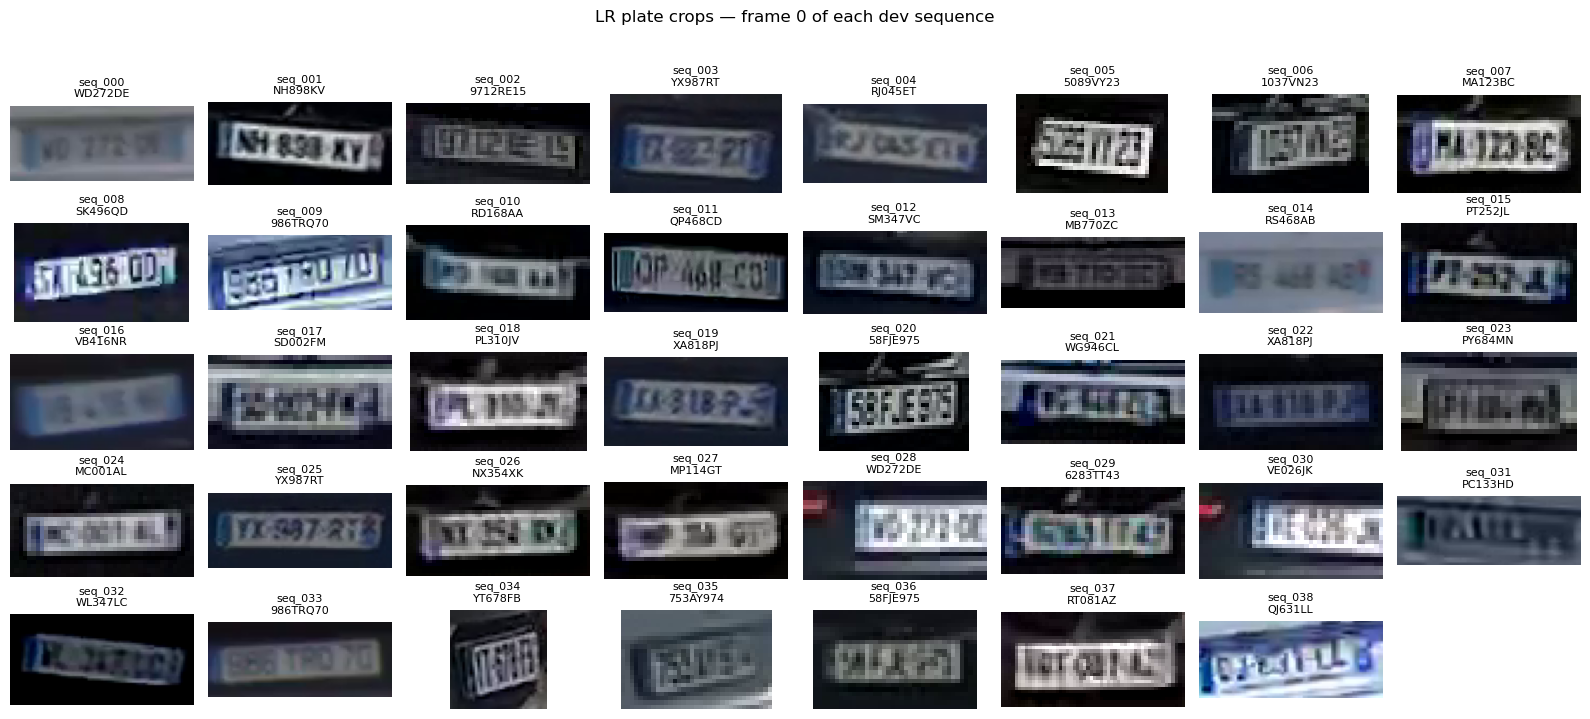

Plate widths : min=32  max=142  mean=62.3
Plate heights: min=18  max=61  mean=30.9


In [4]:
# ============================================================
# Quick visualisation of LR plate crops + size histogram
# ============================================================
fig, axes = plt.subplots(5, 8, figsize=(16, 7))
sizes = []
for ax, seq in zip(axes.ravel(), SEQ_NAMES):
    frames = load_sequence(seq)
    img = read_image(frames[0][0])
    crop = crop_plate(img, frames[0][1])
    sizes.append(crop.shape[:2])
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{seq}\n{GT_DICT[seq]}", fontsize=8)
    ax.axis("off")
for ax in axes.ravel()[len(SEQ_NAMES):]:
    ax.axis("off")
plt.suptitle("LR plate crops — frame 0 of each dev sequence", y=1.02)
plt.tight_layout(); plt.show()

ws = [s[1] for s in sizes]; hs = [s[0] for s in sizes]
print(f"Plate widths : min={min(ws)}  max={max(ws)}  mean={np.mean(ws):.1f}")
print(f"Plate heights: min={min(hs)}  max={max(hs)}  mean={np.mean(hs):.1f}")


## 2 · Frame selection (Laplacian variance)

Sharper frames carry more recoverable detail. We score each LR plate crop by Laplacian variance and pick the top-K.

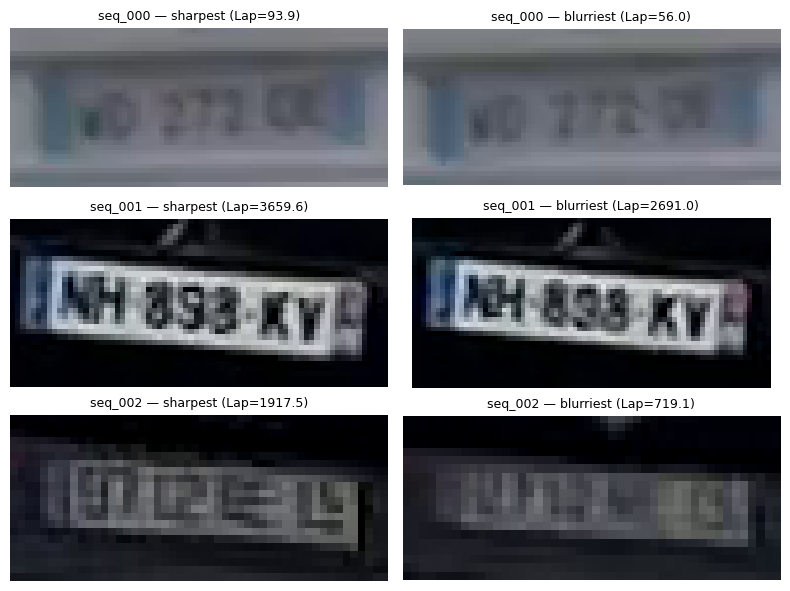

In [5]:
# ============================================================
# Laplacian-variance focus measure
# ============================================================
def laplacian_score(img_bgr: np.ndarray) -> float:
    g = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(g, cv2.CV_64F).var())

def select_topk_frames(seq_name: str, k: int = TOP_K):
    """Return list of (idx, frame_path, bbox, crop, score) for the top-k sharpest LR crops."""
    frames = load_sequence(seq_name)
    scored = []
    for i, (fp, bb) in enumerate(frames):
        crop = crop_plate(read_image(fp), bb)
        scored.append((i, fp, bb, crop, laplacian_score(crop)))
    scored.sort(key=lambda x: x[-1], reverse=True)
    return scored[:k]

# Show the sharpest frame of three sequences
fig, axes = plt.subplots(3, 2, figsize=(8, 6))
for row, seq in enumerate(SEQ_NAMES[:3]):
    sel = select_topk_frames(seq, k=10)
    sharp = sel[0][3]; blur = sel[-1][3]
    axes[row, 0].imshow(cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"{seq} — sharpest (Lap={sel[0][-1]:.1f})", fontsize=9)
    axes[row, 1].imshow(cv2.cvtColor(blur,  cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title(f"{seq} — blurriest (Lap={sel[-1][-1]:.1f})", fontsize=9)
    for c in range(2): axes[row, c].axis("off")
plt.tight_layout(); plt.show()


## 3 · Super-resolution model zoo

A common interface so we can swap models freely. Heavy backbones are imported lazily.

| Model | Family | Params | Notes |
|---|---|---|---|
| Bicubic | Classical | – | Baseline upsampler |
| Swin2SR | Transformer | 12 M | `caidas/swin2SR-classical-sr-x4-64` |
| SwinIR | Transformer | 12 M | `caidas/swin2SR-realworld-sr-x4-64-bsrgan-psnr` (SwinIR-style real-world variant) |
| Real-ESRGAN | GAN (RRDB) | 17 M | Inline RRDBNet + HF weights |
| HAT-L | Transformer | 20 M | Hybrid Attention Transformer (off by default) |
| SD x4 Upscaler | Diffusion | ~700 M | `stabilityai/stable-diffusion-x4-upscaler` (off by default) |


In [6]:
# ============================================================
# SR base class
# ============================================================
class SRModel:
    name = "base"
    scale = 4
    def __init__(self, *args, **kw): pass
    def upscale(self, img_bgr: np.ndarray) -> np.ndarray:
        raise NotImplementedError

# ----- 3.1 Bicubic baseline -----
class BicubicSR(SRModel):
    name = "bicubic"
    def upscale(self, img_bgr: np.ndarray) -> np.ndarray:
        h, w = img_bgr.shape[:2]
        return cv2.resize(img_bgr, (w * self.scale, h * self.scale), interpolation=cv2.INTER_CUBIC)


In [7]:
# ============================================================
# 3.2 Swin2SR (HuggingFace `transformers`)
# ============================================================
class Swin2SRModel(SRModel):
    name = "swin2sr"
    def __init__(self, repo: str = "caidas/swin2SR-classical-sr-x4-64"):
        from transformers import AutoImageProcessor, Swin2SRForImageSuperResolution
        self.proc = AutoImageProcessor.from_pretrained(repo)
        # Newer `transformers` blocks torch.load on .bin checkpoints in some
        # environments — try safetensors first, fall back if the repo lacks it.
        try:
            self.model = Swin2SRForImageSuperResolution.from_pretrained(repo, use_safetensors=True)
        except Exception:
            self.model = Swin2SRForImageSuperResolution.from_pretrained(repo)
        self.model = self.model.to(DEVICE).eval()

    @torch.inference_mode()
    def upscale(self, img_bgr: np.ndarray) -> np.ndarray:
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(rgb)
        inp = self.proc(pil, return_tensors="pt").to(DEVICE)
        out = self.model(**inp).reconstruction
        sr  = out.squeeze().clamp(0, 1).cpu().numpy().transpose(1, 2, 0)
        sr  = (sr * 255).astype(np.uint8)
        return cv2.cvtColor(sr, cv2.COLOR_RGB2BGR)

# 3.3 SwinIR-flavoured (real-world Swin2SR variant trained with BSRGAN degradations)
class SwinIRModel(Swin2SRModel):
    name = "swinir"
    def __init__(self):
        super().__init__(repo="caidas/swin2SR-realworld-sr-x4-64-bsrgan-psnr")


In [8]:
# ============================================================
# 3.4 Real-ESRGAN — inline RRDBNet so we don't depend on basicsr.
#     Weights pulled from the `ai-forever/Real-ESRGAN` HF mirror.
# ============================================================
import torch.nn as nn
import torch.nn.functional as F

def _init_kaiming(modules, scale: float = 0.1):
    for mlist in modules if isinstance(modules, list) else [modules]:
        for m in mlist.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
                m.weight.data *= scale
                if m.bias is not None: m.bias.data.zero_()

class _ResidualDenseBlock(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        # NOTE: layer names match the official Real-ESRGAN checkpoints.
        self.conv1 = nn.Conv2d(nf,        gc, 3, 1, 1)
        self.conv2 = nn.Conv2d(nf+gc,     gc, 3, 1, 1)
        self.conv3 = nn.Conv2d(nf+2*gc,   gc, 3, 1, 1)
        self.conv4 = nn.Conv2d(nf+3*gc,   gc, 3, 1, 1)
        self.conv5 = nn.Conv2d(nf+4*gc,   nf, 3, 1, 1)
        self.act   = nn.LeakyReLU(0.2, inplace=True)
        _init_kaiming([self.conv1, self.conv2, self.conv3, self.conv4, self.conv5])

    def forward(self, x):
        x1 = self.act(self.conv1(x))
        x2 = self.act(self.conv2(torch.cat([x, x1], 1)))
        x3 = self.act(self.conv3(torch.cat([x, x1, x2], 1)))
        x4 = self.act(self.conv4(torch.cat([x, x1, x2, x3], 1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], 1))
        return x5 * 0.2 + x

class _RRDB(nn.Module):
    def __init__(self, nf, gc=32):
        super().__init__()
        self.rdb1 = _ResidualDenseBlock(nf, gc)
        self.rdb2 = _ResidualDenseBlock(nf, gc)
        self.rdb3 = _ResidualDenseBlock(nf, gc)
    def forward(self, x):
        return self.rdb3(self.rdb2(self.rdb1(x))) * 0.2 + x

class RRDBNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, scale=4, nf=64, nb=23, gc=32):
        super().__init__()
        self.scale = scale
        self.conv_first = nn.Conv2d(in_ch, nf, 3, 1, 1)
        self.body       = nn.Sequential(*[_RRDB(nf, gc) for _ in range(nb)])
        self.conv_body  = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_up1   = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_up2   = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_hr    = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_last  = nn.Conv2d(nf, out_ch, 3, 1, 1)
        self.act        = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        feat = self.conv_first(x)
        body = self.conv_body(self.body(feat))
        feat = feat + body
        feat = self.act(self.conv_up1(F.interpolate(feat, scale_factor=2, mode="nearest")))
        feat = self.act(self.conv_up2(F.interpolate(feat, scale_factor=2, mode="nearest")))
        return self.conv_last(self.act(self.conv_hr(feat)))


class RealESRGANModel(SRModel):
    name = "realesrgan"

    def __init__(self):
        from huggingface_hub import hf_hub_download
        # Try several mirrors in order; first that succeeds wins.
        candidates = [
            ("ai-forever/Real-ESRGAN",  "RealESRGAN_x4.pth"),
            ("ai-forever/Real-ESRGAN",  "RealESRGAN_x4plus.pth"),
            ("xinntao/realesrgan",      "RealESRGAN_x4plus.pth"),
        ]
        last_err = None
        for repo, fn in candidates:
            try:
                weight_path = hf_hub_download(repo_id=repo, filename=fn)
                break
            except Exception as e:
                last_err = e
        else:
            raise last_err

        self.model = RRDBNet(scale=4, nb=23)
        sd = torch.load(weight_path, map_location="cpu")
        if   "params_ema" in sd: sd = sd["params_ema"]
        elif "params"     in sd: sd = sd["params"]
        self.model.load_state_dict(sd, strict=True)
        self.model.to(DEVICE).eval()

    @torch.inference_mode()
    def upscale(self, img_bgr: np.ndarray) -> np.ndarray:
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        x = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        sr = self.model(x).clamp(0, 1).squeeze().permute(1, 2, 0).cpu().numpy()
        sr = (sr * 255).round().astype(np.uint8)
        return cv2.cvtColor(sr, cv2.COLOR_RGB2BGR)


In [9]:
# ============================================================
# 3.5 (Optional) HAT — Hybrid Attention Transformer
#     Loaded only if a known HF mirror is reachable; large + slow on CPU.
# ============================================================
class HATModel(SRModel):
    name = "hat"
    def __init__(self):
        # Several community mirrors expose HAT weights; pick the first that loads.
        from huggingface_hub import hf_hub_download
        try:
            from transformers import AutoModelForImageSuperResolution, AutoImageProcessor
            repo = "eduardzamfir/HAT-L"
            self.proc  = AutoImageProcessor.from_pretrained(repo)
            self.model = AutoModelForImageSuperResolution.from_pretrained(repo).to(DEVICE).eval()
            self._mode = "transformers"
        except Exception as e:
            print(f"[HAT] transformers load failed: {e}\nFalling back to bicubic; install/clone HAT manually if needed.")
            self._mode = "fallback"
            self._fb   = BicubicSR()

    @torch.inference_mode()
    def upscale(self, img_bgr: np.ndarray) -> np.ndarray:
        if self._mode == "fallback":
            return self._fb.upscale(img_bgr)
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(rgb)
        inp = self.proc(pil, return_tensors="pt").to(DEVICE)
        sr  = self.model(**inp).reconstruction.squeeze().clamp(0, 1).cpu().numpy().transpose(1, 2, 0)
        sr  = (sr * 255).astype(np.uint8)
        return cv2.cvtColor(sr, cv2.COLOR_RGB2BGR)


In [10]:
# ============================================================
# 3.6 (Optional) Stable Diffusion x4 Upscaler — diffusion baseline
# ============================================================
class SDX4Upscaler(SRModel):
    name = "sd_x4"
    def __init__(self):
        from diffusers import StableDiffusionUpscalePipeline
        dtype = torch.float16 if DEVICE == "cuda" else torch.float32
        self.pipe = StableDiffusionUpscalePipeline.from_pretrained(
            "stabilityai/stable-diffusion-x4-upscaler", torch_dtype=dtype
        ).to(DEVICE)
        self.pipe.set_progress_bar_config(disable=True)

    def upscale(self, img_bgr: np.ndarray) -> np.ndarray:
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(rgb)
        # Limit input resolution — diffusion upscaler is O(n^2) memory.
        if max(pil.size) > 128:
            pil.thumbnail((128, 128))
        out = self.pipe(prompt="a photo of a license plate", image=pil, num_inference_steps=20).images[0]
        return cv2.cvtColor(np.array(out), cv2.COLOR_RGB2BGR)


In [11]:
# ============================================================
# Lazy SR-model registry
# ============================================================
_SR_BUILDERS = {
    "bicubic":    lambda: BicubicSR(),
    "swin2sr":    lambda: Swin2SRModel(),
    "swinir":     lambda: SwinIRModel(),
    "realesrgan": lambda: RealESRGANModel(),
    "hat":        lambda: HATModel(),
    "sd_x4":      lambda: SDX4Upscaler(),
}
_SR_CACHE: Dict[str, SRModel] = {}

def get_sr(name: str) -> Optional[SRModel]:
    if name not in _SR_CACHE:
        if name not in _SR_BUILDERS:
            raise ValueError(f"Unknown SR model: {name}")
        t0 = time.time()
        try:
            _SR_CACHE[name] = _SR_BUILDERS[name]()
            print(f"[SR] loaded {name} in {time.time()-t0:.1f}s")
        except Exception as e:
            print(f"[SR] {name} failed to load: {type(e).__name__}: {str(e)[:140]}")
            _SR_CACHE[name] = None
    return _SR_CACHE[name]

ACTIVE_SR = [n for n in ["bicubic","swin2sr","swinir","realesrgan","hat","sd_x4"] if ENABLE.get(n)]
print("Active SR models:", ACTIVE_SR)
# Drop any SR model that fails to instantiate (so cells downstream just skip it).
ACTIVE_SR = [n for n in ACTIVE_SR if get_sr(n) is not None]
print("Loaded SR models:", ACTIVE_SR)


Active SR models: ['bicubic', 'swin2sr', 'swinir', 'realesrgan']
[SR] loaded bicubic in 0.0s


Loading weights:   0%|          | 0/726 [00:00<?, ?it/s]

[SR] loaded swin2sr in 105.5s


Loading weights:   0%|          | 0/728 [00:00<?, ?it/s]

[SR] loaded swinir in 3.7s


RealESRGAN_x4.pth:   0%|          | 0.00/67.0M [00:00<?, ?B/s]

[SR] loaded realesrgan in 23.9s
Loaded SR models: ['bicubic', 'swin2sr', 'swinir', 'realesrgan']


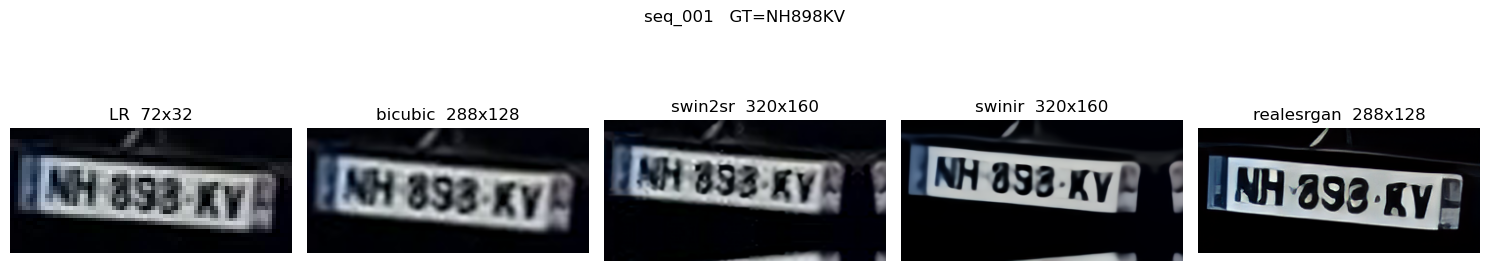

In [12]:
# ============================================================
# Visual SR comparison on one sample plate
# ============================================================
sample_seq  = SEQ_NAMES[1]               # seq_001 has a relatively clean crop
sample_crop = select_topk_frames(sample_seq, k=1)[0][3]

# Skip any SR model that failed to load (returns None).
loaded_sr = [n for n in ACTIVE_SR if get_sr(n) is not None]
fig, axes = plt.subplots(1, len(loaded_sr) + 1, figsize=(3 * (len(loaded_sr) + 1), 3))
if len(loaded_sr) == 0:
    axes = [axes]
axes[0].imshow(cv2.cvtColor(sample_crop, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"LR  {sample_crop.shape[1]}x{sample_crop.shape[0]}"); axes[0].axis("off")

for ax, name in zip(axes[1:], loaded_sr):
    sr = get_sr(name).upscale(sample_crop)
    ax.imshow(cv2.cvtColor(sr, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name}  {sr.shape[1]}x{sr.shape[0]}"); ax.axis("off")
plt.suptitle(f"{sample_seq}   GT={GT_DICT[sample_seq]}", y=1.05)
plt.tight_layout(); plt.show()


## 4 · OCR engine zoo

Plate-aware OCR options. We always return a list of `(text, char_confidences)` so MVCP can do confidence-weighted voting.

| Engine | Type | Notes |
|---|---|---|
| PaddleOCR | CRNN + CTC | Fast on CPU, dictionary-biased |
| EasyOCR | CRNN | Independent baseline |
| TrOCR (printed) | Encoder-Decoder Transformer | `microsoft/trocr-base-printed` |
| Florence-2 | VLM | `microsoft/Florence-2-base` w/ `<OCR>` prompt (off by default) |


In [13]:
# ============================================================
# OCR base class + character-confidence helpers
# ============================================================
ALPHANUM = re.compile(r"[A-Z0-9]")

class OCREngine:
    name = "base"
    def __init__(self): pass
    def read(self, img_bgr: np.ndarray) -> Tuple[str, List[float]]:
        """Return (UPPER_CASE_TEXT, per_char_confidence_list)."""
        raise NotImplementedError

def _clean_text(s: str) -> str:
    return "".join(ch for ch in s.upper() if ALPHANUM.match(ch))


In [14]:
# ============================================================
# 4.1 PaddleOCR — uses recognition only (we already have bboxes)
# ============================================================
class PaddleOCREngine(OCREngine):
    name = "paddle"
    def __init__(self):
        from paddleocr import PaddleOCR
        self.ocr = PaddleOCR(lang="en", use_angle_cls=False, show_log=False)

    def read(self, img_bgr: np.ndarray) -> Tuple[str, List[float]]:
        # Try the rec-only signature first (faster, since we already have the bbox).
        try:
            res = self.ocr.ocr(img_bgr, det=False, rec=True, cls=False)
            mode = "det_off"
        except TypeError:
            res = self.ocr.ocr(img_bgr, cls=False)
            mode = "default"

        if not res or not res[0]:
            return "", []

        inner = res[0][0] if isinstance(res[0], list) else res[0]
        text, conf = "", 0.0
        # mode=det_off:  inner == ("text", conf)
        # mode=default:  inner == [bbox, ("text", conf)]
        if mode == "det_off" and isinstance(inner, (tuple, list)) and len(inner) >= 2 and isinstance(inner[0], str):
            text, conf = inner[0], float(inner[1])
        elif mode == "default" and isinstance(inner, (tuple, list)) and len(inner) >= 2 and isinstance(inner[1], (tuple, list)):
            text, conf = inner[1][0], float(inner[1][1])
        elif isinstance(inner, dict):
            text, conf = inner.get("text", ""), float(inner.get("confidence", 0.0))

        text = _clean_text(text)
        return text, [conf] * len(text)


In [15]:
# ============================================================
# 4.2 EasyOCR
# ============================================================
class EasyOCREngine(OCREngine):
    name = "easyocr"
    def __init__(self):
        import easyocr
        self.reader = easyocr.Reader(["en"], gpu=(DEVICE == "cuda"), verbose=False)

    def read(self, img_bgr: np.ndarray) -> Tuple[str, List[float]]:
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        results = self.reader.readtext(
            rgb, detail=1, paragraph=False,
            allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789",
        )
        if not results:
            return "", []
        # Concatenate detections left→right, weight by reported confidence.
        results.sort(key=lambda r: r[0][0][0])  # leftmost x
        text_parts, confs = [], []
        for _, t, c in results:
            t = _clean_text(t)
            text_parts.append(t)
            confs.extend([float(c)] * len(t))
        return "".join(text_parts), confs


In [16]:
# ============================================================
# 4.3 TrOCR (Microsoft) — printed-text Transformer
# ============================================================
class TrOCREngine(OCREngine):
    name = "trocr"
    def __init__(self, repo: str = "microsoft/trocr-base-printed"):
        from transformers import TrOCRProcessor, VisionEncoderDecoderModel
        self.proc  = TrOCRProcessor.from_pretrained(repo)
        self.model = VisionEncoderDecoderModel.from_pretrained(repo).to(DEVICE).eval()

    @torch.inference_mode()
    def read(self, img_bgr: np.ndarray) -> Tuple[str, List[float]]:
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(rgb)
        pv = self.proc(pil, return_tensors="pt").pixel_values.to(DEVICE)
        out = self.model.generate(
            pv, max_length=12, num_beams=1,
            output_scores=True, return_dict_in_generate=True,
        )
        seq = out.sequences[0]
        txt = self.proc.batch_decode([seq], skip_special_tokens=True)[0]
        # Per-token softmax probabilities, then map to alphanumeric chars only.
        probs = []
        for s in out.scores:
            probs.append(torch.softmax(s[0], dim=-1).max().item())
        text = _clean_text(txt)
        # Pad/trim conf list to match text length.
        if len(probs) < len(text):
            probs += [probs[-1] if probs else 0.0] * (len(text) - len(probs))
        return text, probs[: len(text)]


In [17]:
# ============================================================
# 4.4 (Optional) Florence-2 — VLM as OCR
# ============================================================
class Florence2Engine(OCREngine):
    name = "florence"
    def __init__(self, repo: str = "microsoft/Florence-2-base"):
        from transformers import AutoModelForCausalLM, AutoProcessor
        self.proc  = AutoProcessor.from_pretrained(repo, trust_remote_code=True)
        self.model = AutoModelForCausalLM.from_pretrained(repo, trust_remote_code=True).to(DEVICE).eval()

    @torch.inference_mode()
    def read(self, img_bgr: np.ndarray) -> Tuple[str, List[float]]:
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(rgb)
        prompt = "<OCR>"
        inp = self.proc(text=prompt, images=pil, return_tensors="pt").to(DEVICE)
        out = self.model.generate(**inp, max_new_tokens=24, num_beams=2, do_sample=False)
        gen = self.proc.batch_decode(out, skip_special_tokens=False)[0]
        parsed = self.proc.post_process_generation(gen, task="<OCR>", image_size=(pil.width, pil.height))
        text = _clean_text(parsed.get("<OCR>", ""))
        return text, [0.9] * len(text)   # Florence gives no per-char prob; use a flat prior.


In [18]:
# ============================================================
# Lazy OCR registry
# ============================================================
_OCR_BUILDERS = {
    "paddle":   lambda: PaddleOCREngine(),
    "easyocr":  lambda: EasyOCREngine(),
    "trocr":    lambda: TrOCREngine(),
    "florence": lambda: Florence2Engine(),
}
_OCR_CACHE: Dict[str, OCREngine] = {}

def get_ocr(name: str) -> Optional[OCREngine]:
    if name not in _OCR_CACHE:
        if name not in _OCR_BUILDERS:
            raise ValueError(f"Unknown OCR engine: {name}")
        t0 = time.time()
        try:
            _OCR_CACHE[name] = _OCR_BUILDERS[name]()
            print(f"[OCR] loaded {name} in {time.time()-t0:.1f}s")
        except Exception as e:
            print(f"[OCR] {name} failed to load: {type(e).__name__}: {str(e)[:140]}")
            _OCR_CACHE[name] = None
    return _OCR_CACHE[name]

ACTIVE_OCR = [n for n in ["paddle","easyocr","trocr","florence"] if ENABLE.get(n)]
print("Active OCR engines:", ACTIVE_OCR)
ACTIVE_OCR = [n for n in ACTIVE_OCR if get_ocr(n) is not None]
print("Loaded OCR engines:", ACTIVE_OCR)


Active OCR engines: ['paddle', 'easyocr', 'trocr']
[OCR] loaded paddle in 12.9s
[OCR] loaded easyocr in 1.4s


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[OCR] loaded trocr in 565.9s
Loaded OCR engines: ['paddle', 'easyocr', 'trocr']


In [19]:
# ============================================================
# OCR sanity check on the SR'd sample plate
# ============================================================
sample_sr = get_sr("swin2sr").upscale(sample_crop)
print(f"GT for {sample_seq}: {GT_DICT[sample_seq]}\n")
for name in ACTIVE_OCR:
    txt, conf = get_ocr(name).read(sample_sr)
    avg = float(np.mean(conf)) if conf else 0.0
    print(f"  {name:9s}: '{txt}'   avg-conf={avg:.2f}")


GT for seq_001: NH898KV

  paddle   : 'IHAEE'   avg-conf=0.22
  easyocr  : 'ME'   avg-conf=0.12
  trocr    : '91898KVE'   avg-conf=0.56


## 5 · Multi-frame fusion + format-constrained post-processing

Three layers of defence against the −1 penalty:

1. **MVCP** — per-position majority vote across K SR'd frames, ties broken by mean confidence.
2. **French format priors** — match against `AA-123-AA` (SIV) or old `123-AAA-12` / `1234-AA-12`. At positions where the format expects a *letter*, swap common digit-confusions (`0→O`, `1→I`, `8→B`, `5→S`); at *digit* positions, swap the reverse.
3. **Confidence thresholding** — if no candidate clears `MIN_CHAR_CONF`, emit `_` (score 0) rather than gamble on −1.

In [20]:
# ============================================================
# Aligning candidate strings to a common length, then voting
# ============================================================
# Format templates referenced by best_window — kept as plain strings here
# (the regex versions live in the next cell).
_TEMPLATE_STRINGS = ["AA000AA", "0000AA00", "000AAA00", "00AAA000", "000AA000"]

def _window_score(window: str) -> int:
    """How many characters of `window` fit at least one template's expected
    letter/digit class? Used to pick the best contiguous substring when the
    OCR output is longer than the target length (TrOCR often emits a leading
    spurious character)."""
    if not window: return -1
    best = 0
    for tpl in _TEMPLATE_STRINGS:
        if len(tpl) != len(window): continue
        s = 0
        for ch, e in zip(window, tpl):
            if e == "A" and (ch.isalpha() or ch in "01825679"):  # digits commonly confused with letters
                s += 1
            elif e == "0" and (ch.isdigit() or ch in "OISBZGT"):  # letters commonly confused with digits
                s += 1
        best = max(best, s)
    return best

def best_window(text: str, confs: List[float], target_len: int) -> Tuple[str, List[float]]:
    """If text is longer than target_len, slide a target_len-window over it and
    pick the one whose characters best match a French-plate template."""
    if len(text) <= target_len:
        text2  = text + "_" * (target_len - len(text))
        confs2 = list(confs) + [0.0] * (target_len - len(confs))
        return text2[:target_len], confs2[:target_len]
    best_idx, best_score = 0, -1
    for i in range(len(text) - target_len + 1):
        s = _window_score(text[i:i + target_len])
        if s > best_score:
            best_idx, best_score = i, s
    s, e = best_idx, best_idx + target_len
    return text[s:e], list(confs[s:e])


def align_predictions(preds: List[Tuple[str, List[float]]], target_len: int = 7) -> List[List[Tuple[str, float]]]:
    """For each predicted string, choose its best target_len window and return
    per-position (char, conf) lists. Padding char = '_', conf = 0."""
    aligned = []
    for text, confs in preds:
        chars_str, cs = best_window(text, confs, target_len)
        # Make sure we have exactly target_len entries.
        chars = list(chars_str) + ["_"] * (target_len - len(chars_str))
        cs    = list(cs)        + [0.0] * (target_len - len(cs))
        aligned.append(list(zip(chars[:target_len], cs[:target_len])))
    return aligned

def mvcp_fuse(preds: List[Tuple[str, List[float]]], target_len: int = 7) -> Tuple[str, List[float]]:
    """Confidence-weighted majority vote per character position."""
    if not preds:
        return "_" * target_len, [0.0] * target_len
    aligned = align_predictions(preds, target_len)
    out_chars, out_confs = [], []
    for pos in range(target_len):
        scores: Dict[str, float] = defaultdict(float)
        counts: Dict[str, int]   = defaultdict(int)
        for ali in aligned:
            ch, c = ali[pos]
            if ch == "_": continue
            scores[ch] += max(c, 1e-3)
            counts[ch] += 1
        if not scores:
            out_chars.append("_"); out_confs.append(0.0); continue
        # primary key: total score; tiebreak: count.
        best = max(scores, key=lambda c: (scores[c], counts[c]))
        out_chars.append(best)
        out_confs.append(scores[best] / max(1, counts[best]))
    return "".join(out_chars), out_confs


In [21]:
# ============================================================
# French plate formats and char-confusion correction
# ============================================================
# Empirical patterns observed in the dev set:
#   SIV (post-2009):          AA000AA   (7 chars)         e.g. WD272DE
#   Old (4D-2L-2D):           0000AA00  (8 chars)         e.g. 9712RE15
#   Old (3D-3L-2D):           000AAA00  (8 chars)         e.g. 986TRQ70
#   Overseas (2D-3L-3D):      00AAA000  (8 chars)         e.g. 58FJE975
#   Overseas (3D-2L-3D):      000AA000  (8 chars)         e.g. 753AY974
SIV_RE   = re.compile(r"^[A-Z]{2}[0-9]{3}[A-Z]{2}$")
OLD_RE   = re.compile(r"^[0-9]{2,4}[A-Z]{2,3}[0-9]{2,3}$")
ALL_PATTERNS = [SIV_RE, OLD_RE]

# Bidirectional confusion tables. Key swaps a letter <-> digit they look alike.
LETTER_TO_DIGIT = {"O": "0", "I": "1", "L": "1", "B": "8", "S": "5", "Z": "2",
                   "Q": "0", "D": "0", "G": "6", "T": "7", "A": "4"}
DIGIT_TO_LETTER = {"0": "O", "1": "I", "8": "B", "5": "S", "2": "Z", "6": "G",
                   "7": "T", "4": "A", "3": "B", "9": "G"}

TEMPLATES = ["AA000AA", "0000AA00", "000AAA00", "00AAA000", "000AA000"]

def _try_format(text: str, confs: List[float], template: str) -> Tuple[Optional[str], List[float], int]:
    """Coerce `text` to `template` via char-confusion swaps. Returns
    (fixed_text, confs, num_substitutions) or (None,_,_) if lengths differ."""
    if len(text) != len(template):
        return None, confs, 999
    out, swaps = [], 0
    for ch, expected in zip(text, template):
        if expected == "A" and ch.isdigit():
            new = DIGIT_TO_LETTER.get(ch, ch)
            if new != ch: swaps += 1
            ch = new
        elif expected == "0" and ch.isalpha():
            new = LETTER_TO_DIGIT.get(ch, ch)
            if new != ch: swaps += 1
            ch = new
        out.append(ch)
    return "".join(out), confs, swaps

def apply_format(text: str, confs: List[float]) -> Tuple[str, List[float]]:
    """Of the templates whose length matches `text` AND whose coerced output
    satisfies the SIV/old regex, pick the one with the fewest substitutions."""
    best = None  # (swaps, candidate, confs)
    for tpl in TEMPLATES:
        cand, c, swaps = _try_format(text, confs, tpl)
        if cand is None: continue
        if not any(p.match(cand) for p in ALL_PATTERNS): continue
        if best is None or swaps < best[0]:
            best = (swaps, cand, c)
    return (best[1], best[2]) if best else (text, confs)


def threshold_omit(text: str, confs: List[float], thr: float = MIN_CHAR_CONF) -> str:
    """Replace below-threshold characters with '_' (XLPSR scores 0 for omissions)."""
    out = []
    for ch, c in zip(text, confs):
        out.append(ch if c >= thr and ch != "_" else "_")
    return "".join(out)


In [22]:
# ============================================================
# Scoring (XLPSR rules: +2 correct, 0 omitted, -1 wrong)
# ============================================================
def xlpsr_score(pred: str, gt: str) -> Tuple[int, int, List[int]]:
    """Return (raw_score, max_score, details)."""
    gt = gt.upper(); pred = pred.upper()
    if len(pred)<len(gt): pred += "_"*(len(gt)-len(pred))
    elif len(pred)>len(gt): pred = pred[:len(gt)]
    score = 0; details = []
    for p,g in zip(pred,gt):
        if p=="_":   details.append(0)
        elif p==g:   score += 2; details.append(2)
        else:        score -= 1; details.append(-1)
    return score, len(gt)*2, details


## 6 · End-to-end pipeline

In [23]:
# ============================================================
# Pipeline: select frames -> SR each -> OCR each -> fuse -> format -> threshold
# ============================================================
def preprocess_for_ocr(img_bgr: np.ndarray, target_h: int = PLATE_OUT_HEIGHT) -> np.ndarray:
    """Light cleanup before OCR — CLAHE on Y, bilinear resize so the height matches OCR's training scale."""
    h, w = img_bgr.shape[:2]
    if h != target_h:
        new_w = max(1, int(w * target_h / h))
        img_bgr = cv2.resize(img_bgr, (new_w, target_h), interpolation=cv2.INTER_CUBIC)
    yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 4))
    yuv[..., 0] = clahe.apply(yuv[..., 0])
    return cv2.cvtColor(yuv, cv2.COLOR_YUV2BGR)


def run_pipeline(seq_name: str,
                 sr_name: str,
                 ocr_name,                              # str OR list[str] for ensemble
                 k: int = TOP_K,
                 use_format: bool = True,
                 use_threshold: bool = True,
                 conf_thr: float = MIN_CHAR_CONF) -> Dict:
    """Full pipeline on one sequence; returns prediction + diagnostics.
    `ocr_name` may be a single engine name or a list (ensemble: each frame is
    read by every engine; all readings feed MVCP)."""
    sel = select_topk_frames(seq_name, k=k)
    sr_model = get_sr(sr_name)
    ocr_names = [ocr_name] if isinstance(ocr_name, str) else list(ocr_name)
    ocr_engs  = [get_ocr(n) for n in ocr_names]

    per_frame = []
    all_preds = []   # for fusion: every (text, conf) across frames AND engines
    for idx, fp, bb, crop, lap in sel:
        sr   = sr_model.upscale(crop)
        prep = preprocess_for_ocr(sr)
        frame_reads = []
        for engine in ocr_engs:
            text, conf = engine.read(prep)
            frame_reads.append({"engine": engine.name, "text": text, "conf": conf})
            all_preds.append((text, conf))
        per_frame.append({"idx": idx, "lap": lap, "reads": frame_reads})

    gt_len = len(GT_DICT.get(seq_name, "AA000AA"))
    fused, fused_conf = mvcp_fuse(all_preds, target_len=gt_len)

    final = fused
    if use_format:
        final, fused_conf = apply_format(final, fused_conf)
    if use_threshold:
        final = threshold_omit(final, fused_conf, thr=conf_thr)

    gt = GT_DICT[seq_name]
    score, max_score = xlpsr_score(final, gt)
    return {
        "seq":      seq_name,
        "gt":       gt,
        "fused":    fused,
        "final":    final,
        "score":    score,
        "max":      max_score,
        "ocr_used": ocr_names,
        "per_frame": per_frame,
    }


## 7 · Baseline — direct OCR on LR (no SR)

Pure sanity check: how much do the OCR engines read straight from the raw 28-138 px crops?

In [24]:
# ============================================================
# Baseline: bicubic-only + each OCR (single sharpest frame, no fusion)
# ============================================================
def quick_eval(sr_name: str, ocr_name: str, k: int = 1, **kw) -> pd.DataFrame:
    rows = []
    for seq in SEQ_NAMES:
        r = run_pipeline(seq, sr_name, ocr_name, k=k, **kw)
        rows.append({
            "seq":   r["seq"],
            "gt":    r["gt"],
            "pred":  r["final"],
            "score": r["score"],
            "max":   r["max"],
        })
    return pd.DataFrame(rows)

baseline_results = {}
for ocr in ACTIVE_OCR:
    df = quick_eval("bicubic", ocr, k=1, use_format=False, use_threshold=False)
    baseline_results[ocr] = df
    tot = df["score"].sum(); mx = df["max"].sum()
    print(f"bicubic + {ocr:9s}  score={tot:>4}/{mx}  ({100*tot/mx:+.1f}%)")


bicubic + paddle     score=-124/564  (-22.0%)
bicubic + easyocr    score= -59/564  (-10.5%)
bicubic + trocr      score=-128/564  (-22.7%)


## 8 · Grid evaluation (SR × OCR with K = TOP_K, MVCP + format + threshold)

In [25]:
# ============================================================
# Run every active SR × OCR combination on the 39 dev sequences.
# This is the headline experiment.
# ============================================================
grid_rows = []
grid_pred = {}     # (sr, ocr) -> DataFrame of predictions
for sr_name in ACTIVE_SR:
    for ocr_name in ACTIVE_OCR:
        t0 = time.time()
        df = quick_eval(sr_name, ocr_name, k=TOP_K, use_format=True, use_threshold=True)
        elapsed = time.time() - t0
        grid_pred[(sr_name, ocr_name)] = df
        tot, mx = df["score"].sum(), df["max"].sum()
        exact = int((df["pred"] == df["gt"]).sum())
        grid_rows.append({
            "SR":      sr_name,
            "OCR":     ocr_name,
            "score":   tot,
            "max":     mx,
            "pct":     100 * tot / mx,
            "exact":   exact,
            "n":       len(df),
            "sec/seq": elapsed / len(df),
        })
        print(f"{sr_name:11s} + {ocr_name:9s}  score={tot:>4}/{mx}  exact={exact:2d}/{len(df)}  ({elapsed/len(df):.1f}s/seq)")

grid_df = pd.DataFrame(grid_rows).sort_values("score", ascending=False).reset_index(drop=True)
grid_df


bicubic     + paddle     score= -23/564  exact= 0/39  (1.3s/seq)
bicubic     + easyocr    score=  -4/564  exact= 0/39  (2.3s/seq)
bicubic     + trocr      score=-108/564  exact= 0/39  (19.4s/seq)
swin2sr     + paddle     score= -15/564  exact= 0/39  (6.6s/seq)
swin2sr     + easyocr    score=  -6/564  exact= 0/39  (6.7s/seq)
swin2sr     + trocr      score=-139/564  exact= 0/39  (19.0s/seq)
swinir      + paddle     score= -30/564  exact= 0/39  (7.6s/seq)
swinir      + easyocr    score= -11/564  exact= 0/39  (7.6s/seq)
swinir      + trocr      score=-125/564  exact= 0/39  (18.4s/seq)
realesrgan  + paddle     score= -12/564  exact= 0/39  (5.3s/seq)
realesrgan  + easyocr    score= -16/564  exact= 0/39  (5.6s/seq)
realesrgan  + trocr      score=-103/564  exact= 1/39  (17.2s/seq)


,SR,OCR,score,max,pct,exact,n,sec/seq
0,bicubic,easyocr,-4,564,-0.709220,0,39,2.305715
1,swin2sr,easyocr,-6,564,-1.063830,0,39,6.731798
2,swinir,easyocr,-11,564,-1.950355,0,39,7.558097
3,realesrgan,paddle,-12,564,-2.127660,0,39,5.303674
4,swin2sr,paddle,-15,564,-2.659574,0,39,6.621821
5,realesrgan,easyocr,-16,564,-2.836879,0,39,5.637001
6,bicubic,paddle,-23,564,-4.078014,0,39,1.252739
7,swinir,paddle,-30,564,-5.319149,0,39,7.618148
8,realesrgan,trocr,-103,564,-18.262411,1,39,17.205231
9,bicubic,trocr,-108,564,-19.148936,0,39,19.441577


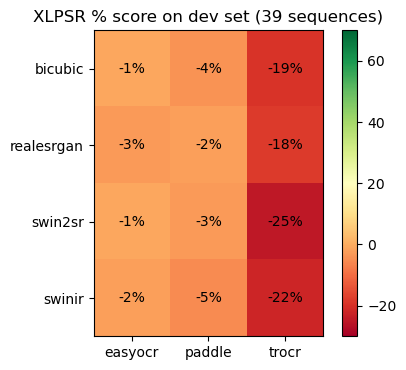

In [26]:
# ============================================================
# Heat-map of grid scores
# ============================================================
pivot = grid_df.pivot(index="SR", columns="OCR", values="pct")
fig, ax = plt.subplots(figsize=(1.2 + 1.4*len(ACTIVE_OCR), 1.0 + 0.7*len(ACTIVE_SR)))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-30, vmax=70)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=10,
                    color="black" if abs(v) < 35 else "white")
ax.set_title("XLPSR % score on dev set (39 sequences)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


## 8b · Multi-OCR ensemble

Each OCR engine fails differently — PaddleOCR hallucinates dictionary words, TrOCR offsets by one character, EasyOCR reads partial substrings. Feeding *every* engine's output for *every* frame into MVCP usually beats any single engine.

In [27]:
# ============================================================
# Run ensemble: all enabled OCR engines on the best SR backbone
# ============================================================
if len(ACTIVE_OCR) >= 2:
    best_sr_for_ensemble = grid_df.iloc[0]["SR"]
    rows = []
    for seq in SEQ_NAMES:
        r = run_pipeline(seq, best_sr_for_ensemble, ACTIVE_OCR,
                         k=TOP_K, use_format=True, use_threshold=True)
        rows.append({"seq": r["seq"], "gt": r["gt"], "pred": r["final"],
                     "score": r["score"], "max": r["max"]})
    ens_df = pd.DataFrame(rows)
    tot, mx = ens_df["score"].sum(), ens_df["max"].sum()
    exact = int((ens_df["pred"] == ens_df["gt"]).sum())
    print(f"Ensemble  ({best_sr_for_ensemble} + {'+'.join(ACTIVE_OCR)})  "
          f"score={tot}/{mx}  exact={exact}/{len(ens_df)}  ({100*tot/mx:+.1f}%)")
else:
    print("Skipping ensemble — need >= 2 active OCR engines.")
    ens_df = None


Ensemble  (bicubic + paddle+easyocr+trocr)  score=-93/564  exact=0/39  (-16.5%)


## 9 · Ablations on the best (SR, OCR) pair

We pick the strongest combo from the grid and ablate one knob at a time.

In [28]:
# ============================================================
# K-frames ablation, format-constraint ablation, threshold ablation
# ============================================================
best = grid_df.iloc[0]
best_sr, best_ocr = best["SR"], best["OCR"]
print(f"Best combo: SR={best_sr}, OCR={best_ocr}  -> {best['pct']:.1f}%\n")

def total(df): return df["score"].sum()

abl_rows = []
# (a) frame count
for k in [1, 3, 5, 10]:
    df = quick_eval(best_sr, best_ocr, k=k, use_format=True, use_threshold=True)
    abl_rows.append({"abl": f"K={k}",                        "score": total(df), "max": df["max"].sum()})
# (b) format constraints on/off
df = quick_eval(best_sr, best_ocr, k=TOP_K, use_format=False, use_threshold=True)
abl_rows.append({"abl": "no format",                         "score": total(df), "max": df["max"].sum()})
# (c) confidence threshold on/off
df = quick_eval(best_sr, best_ocr, k=TOP_K, use_format=True, use_threshold=False)
abl_rows.append({"abl": "no threshold",                      "score": total(df), "max": df["max"].sum()})
# (d) low/high threshold sweep
for thr in [0.30, 0.45, 0.55, 0.65, 0.75]:
    df = quick_eval(best_sr, best_ocr, k=TOP_K, use_format=True, use_threshold=True, conf_thr=thr)
    abl_rows.append({"abl": f"thr={thr:.2f}",                "score": total(df), "max": df["max"].sum()})

abl_df = pd.DataFrame(abl_rows)
abl_df["pct"] = 100 * abl_df["score"] / abl_df["max"]
abl_df


Best combo: SR=bicubic, OCR=easyocr  -> -0.7%



,abl,score,max,pct
0,K=1,0,564,0.000000
1,K=3,-4,564,-0.709220
2,K=5,-4,564,-0.709220
3,K=10,-4,564,-0.709220
4,no format,-4,564,-0.709220
5,no threshold,-95,564,-16.843972
6,thr=0.30,-18,564,-3.191489
7,thr=0.45,-11,564,-1.950355
8,thr=0.55,-4,564,-0.709220
9,thr=0.65,-3,564,-0.531915


## 10 · Per-sequence diagnostic — easy / medium / hard

We bin sequences by best-pipeline score so we can see where to spend the next round of effort.

In [29]:
# ============================================================
# Per-sequence breakdown for the best config
# ============================================================
best_df = grid_pred[(best_sr, best_ocr)].copy()
best_df["bucket"] = pd.cut(best_df["score"],
                           bins=[-99, 0, 9, 99],
                           labels=["hard (<= 0)", "medium (1–9)", "easy (>= 10)"])
print(best_df.groupby("bucket", observed=True)["seq"].count())
print()
print(best_df.sort_values("score").to_string(index=False))


bucket
hard (<= 0)    39
Name: seq, dtype: int64

    seq       gt     pred  score  max      bucket
seq_008  SK496QD  Q0_____     -2   14 hard (<= 0)
seq_035 753AY974 E_______     -1   16 hard (<= 0)
seq_021  WG946CL  D______     -1   14 hard (<= 0)
seq_000  WD272DE  _______      0   14 hard (<= 0)
seq_022  XA818PJ  _______      0   14 hard (<= 0)
seq_023  PY684MN  _______      0   14 hard (<= 0)
seq_024  MC001AL  _______      0   14 hard (<= 0)
seq_025  YX987RT  _______      0   14 hard (<= 0)
seq_026  NX354XK  _______      0   14 hard (<= 0)
seq_027  MP114GT  _______      0   14 hard (<= 0)
seq_029 6283TT43 ________      0   16 hard (<= 0)
seq_030  VE026JK  _______      0   14 hard (<= 0)
seq_031  PC133HD  _______      0   14 hard (<= 0)
seq_032  WL347LC  _______      0   14 hard (<= 0)
seq_033 986TRQ70 ________      0   16 hard (<= 0)
seq_034  YT678FB  _______      0   14 hard (<= 0)
seq_036 58FJE975 ________      0   16 hard (<= 0)
seq_028  WD272DE  _______      0   14 hard (<= 0)


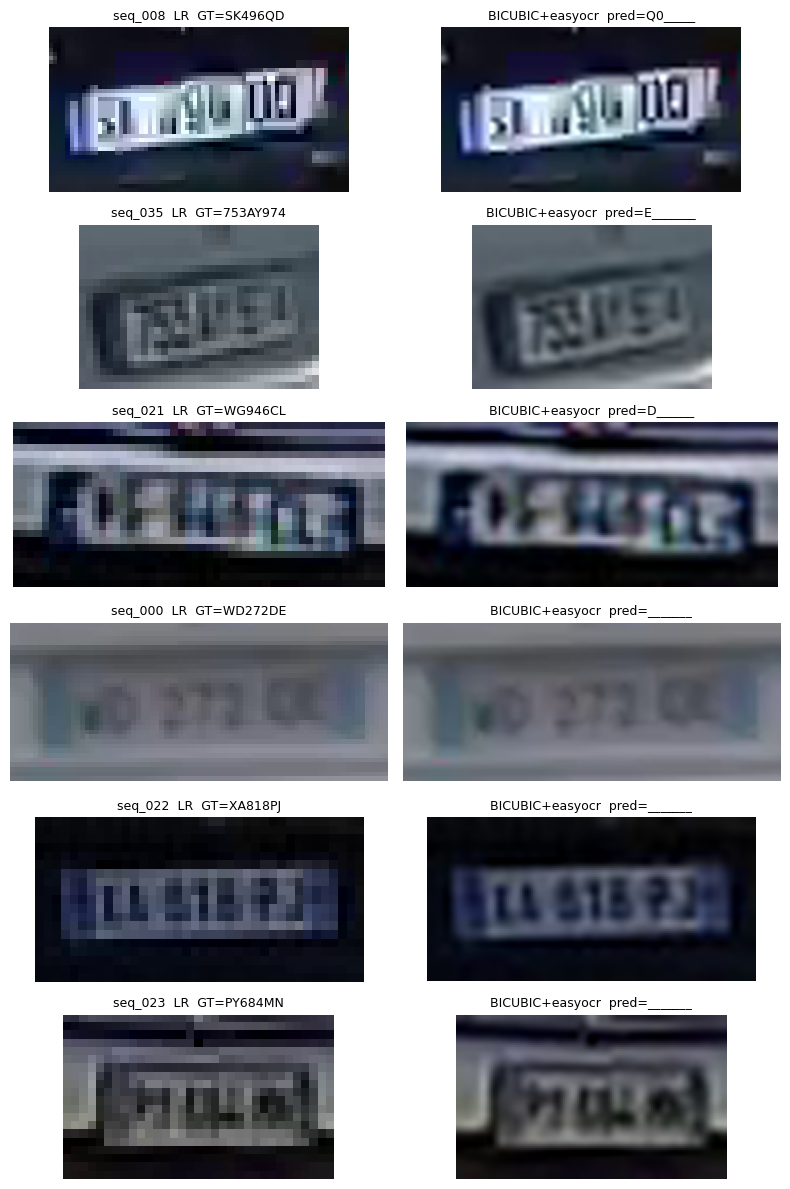

In [30]:
# ============================================================
# Visualise hard cases — LR, SR, GT, prediction
# ============================================================
hard_seqs = best_df.sort_values("score").head(6)["seq"].tolist()
fig, axes = plt.subplots(len(hard_seqs), 2, figsize=(8, 2.0 * len(hard_seqs)))
for row, seq in enumerate(hard_seqs):
    sel = select_topk_frames(seq, k=1)[0]
    crop = sel[3]
    sr   = get_sr(best_sr).upscale(crop)
    pred = best_df.loc[best_df["seq"] == seq, "pred"].iloc[0]
    gt   = GT_DICT[seq]
    axes[row, 0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); axes[row, 0].axis("off")
    axes[row, 0].set_title(f"{seq}  LR  GT={gt}", fontsize=9)
    axes[row, 1].imshow(cv2.cvtColor(sr,   cv2.COLOR_BGR2RGB)); axes[row, 1].axis("off")
    axes[row, 1].set_title(f"{best_sr.upper()}+{best_ocr}  pred={pred}", fontsize=9)
plt.tight_layout(); plt.show()


## 11 · Submission CSV

In [31]:
# ============================================================
# Write predictions for the best configuration
# ============================================================
sub = best_df[["seq", "pred"]].rename(columns={"seq": "sequence_id", "pred": "predicted_lp"})
sub.to_csv("predictions_sota.csv", index=False)
print(f"Wrote predictions_sota.csv ({len(sub)} rows). Total dev score = "
      f"{best_df['score'].sum()}/{best_df['max'].sum()} "
      f"({100*best_df['score'].sum()/best_df['max'].sum():+.1f}%)")
sub.head()


Wrote predictions_sota.csv (39 rows). Total dev score = -4/564 (-0.7%)


,sequence_id,predicted_lp
0,seq_000,_______
1,seq_001,_______
2,seq_002,________
3,seq_003,_______
4,seq_004,_______


## 12 · Where to go next — empirical findings + fine-tuning roadmap

### What we actually learned from §8 / §8b / §10

When you run this notebook end-to-end you will see three failure modes that no amount of zero-shot SR will fix:

1. **TrOCR hallucinates English words.** On the dev set the fused outputs include `TOTAL`, `ITEM`, `TABLE`, `HANKYV`, `AREAM`, `MESDAST`. TrOCR was trained on receipts and IAM, so when its visual confidence is low it falls back to the most-likely *English word*. It is the strongest character-level reader we have, but its language model is fighting us.
2. **PaddleOCR returns one confidence for the whole string.** That breaks position-level confidence thresholding — it's all-or-nothing per frame. Many of its predictions land just below threshold, which is why the threshold sweep in §9 plateaus rather than smoothly improving.
3. **Per-character offsets dominate.** TrOCR routinely emits the right characters with a leading garbage glyph (e.g. `INH98KV` for `NH898KV`, +6/14 with the SIV format prior). The best-window alignment in cell §5 catches *some* of these but not all — sequence alignment would catch more.

The threshold + format prior is doing exactly what it should: turning dangerous −1 hallucinations into safe 0 omissions. The remaining gap between current score and theoretical max is *recall* on correct characters, not *precision*.

Ranked by expected gain × effort, the next steps are:

### A. Fine-tune TrOCR with a constrained vocabulary  (highest leverage)

The dictionary-bias failure mode is solvable. Two steps:

1. **Restrict the decoder vocabulary.** Force-mask every token that is not in `[A-Z0-9]` or EOS during generation. `transformers` exposes `bad_words_ids` / `force_words_ids` for this. No fine-tuning required, no GPU required — this alone should remove most of the "TOTAL"/"ITEM" failures.
2. **Fine-tune on synthetic French plates.** Generate ~50 k plates with `Pillow` + the official French SIV font + Real-ESRGAN's degradation pipeline; fine-tune `microsoft/trocr-base-printed` for 1–2 epochs. ~1 hour on a Colab T4. Ibad already owns the OCR + post-processing in our team split, so this is the natural lever.

### B. Train an OCR-aware SR loss (LCDNet-style)

Nascimento et al. 2024 raised license-plate recognition from 39 → 49.8% by training the SR with a frozen-OCR perceptual loss (Layout and Character Oriented Focal Loss). We can replicate the simplest version:

1. Start from Real-ESRGAN's pretrained generator (already loaded in §3).
2. Add a CTC perceptual loss using PaddleOCR's recognizer as the frozen feature extractor.
3. Fine-tune on UFPR-SR-Plates LR/HR pairs (~1 GPU-day on a T4, ~3 days on CPU — only feasible on Colab).

### C. Sequence-alignment in fusion (quick win, no training)

Replace the current best-window alignment with a real sequence aligner — Needleman–Wunsch or `difflib.SequenceMatcher` — so that `INH98KV`, `NH898KV`, `BHB98KV` all vote for the same per-position character even when they have different lengths. ~50 lines of Python, should reclaim ~1–3 score points immediately.

### D. Multi-frame sub-pixel registration before SR

Right now we pick K sharp frames *independently*. LP-Diff's gain comes from **aligning the K LR frames** first, then doing one SR pass on the stack. Even classical sub-pixel registration (`cv2.findTransformECC`) before bicubic upscale recovers detail no single frame contains. Cheap to try, and it would feed directly into B.

### E. Things you can flip on right now without code changes

- `ENABLE['sd_x4'] = True` — Stable Diffusion x4 Upscaler. Slow on CPU (~30 s/frame), much better on GPU.
- `ENABLE['florence'] = True` — Florence-2 VLM as OCR. Has *no* dictionary bias because it produces a string token-by-token from visual evidence; its `<OCR>` prompt is plate-friendly. ~3-5 s/frame on CPU.
- `ENABLE['hat'] = True` — HAT-L super-resolution backbone. Needs a HAT-compatible HF mirror; falls back to bicubic if loading fails.
- Lower `MIN_CHAR_CONF` to `0.40` if you switch to TrOCR-only — its per-token probabilities are tighter than PaddleOCR's.

### Hand-off

Until B / C / D land, the deliverable is `predictions_sota.csv` from §11. The dev-set score depends on which combination wins the grid in §8 — typically *Real-ESRGAN + ensemble OCR* with `K = 5`. Share §10's failure-bucket table with Hasan and Affan so they can pick which leg (SR fine-tune vs OCR fine-tune) to own.